# Testing SR-IS vs SR on 4-room replanning

In [33]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

import gym_env
from utils import test_agent, create_mapping_nb
from models import SR_IS, SR_TD

In [ ]:
# Set the seeds
seeds = np.arange(50)

# Save dir
save_dir = os.path.join('..', 'figures/')
checkpoint_dir = os.path.join('..','checkpoints/4room/')

# Model colors
MODEL_COLORS = {
    'Random':   '#9E9E9E',
    'SR':       '#E8883A',
    'SR*':      '#F5BC72',
    'SR-IS':    '#4A90C4',
    'Complete': '#8FC0E0',
}

In [35]:
# Model Hyperparams 
reward = -0.1
term_reward = 10
alpha = 0.05
beta = 1.0
_lambda = 1.0
num_steps = 15000
num_simulations = 20

# Original term state
learn_term_state = (0,6)

# New term states
term_states = {
    "same" : [(0,4), (2,6)],
    "different" : [(4,6), (6,4), (6,6), (4,0), (6,0), (6,2)],
}

In [36]:
env = gym.make("four-room-sg")
maze = env.unwrapped.maze
mapping = create_mapping_nb(env.unwrapped.maze, env.unwrapped.get_walls())

In [37]:
avgs_random = {
    'same':{'mean':[],'median':[]},
    'different':{'mean':[],'median':[]}
}
avgs_sr = {
    'same':{'mean':[],'median':[]},
    'different':{'mean':[],'median':[]}
}
avgs_sr_is = {
    'same':{'mean':[],'median':[]},
    'different':{'mean':[],'median':[]}
}

In [38]:
# Loop through the seeds
for seed in seeds:
    print(f"Seed: {seed}")
    ##  Learning Phase  ##
    # Initialize agents
    SR_IS_agent = SR_IS(env_name="four-room-sg", reward=reward, term_reward=reward, _lambda=_lambda, beta=beta, alpha=alpha, num_steps=num_steps, policy="softmax", imp_samp=True)
    Random_agent = SR_IS(env_name="four-room-sg", reward=reward, term_reward=reward, _lambda=_lambda, beta=beta, num_steps=num_steps, policy="random", imp_samp=False)
    SR_agent = SR_TD(env_name="four-room-tr", gamma=0.9, reward=0,  term_reward=10, beta=beta, alpha=0.05, num_steps=num_steps, policy="softmax")

    # Base reward vectors
    r_base_is = np.copy(SR_IS_agent.r)
    r_base_sr = np.zeros(len(SR_agent.r))

    # Learning reward vectors
    # SR-IS
    r_learn_is = np.copy(SR_IS_agent.r)
    r_learn_is[mapping[learn_term_state]] = term_reward
    SR_IS_agent.expr_t = np.exp(r_learn_is[SR_IS_agent.terminals] / _lambda)
    SR_IS_agent.r = r_learn_is

    # SR
    r_learn_sr = np.copy(SR_agent.r)
    r_learn_sr[mapping[learn_term_state]] = term_reward
    SR_agent.r = r_learn_sr

    # Learn
    SR_IS_agent.learn(seed=int(seed))
    SR_agent.learn(seed=int(seed))


    ##  Reval Phase  ##
    # Loop through the different terminal states
    for room, terminal_locs in term_states.items():
        # Loop through the different terminal locations
        for term_loc in terminal_locs:
            term_idx = mapping[term_loc]
            # Construct new reward vectors for SR-IS and SR agents
            r_new_is = np.copy(r_base_is)
            r_new_is[term_idx] = term_reward
            r_new_sr = np.copy(r_base_sr)
            r_new_sr[term_idx] = term_reward

            # Use new reward vector to update representations
            SR_IS_agent.r = r_new_is
            SR_agent.r = r_new_sr

            # Update SR-IS
            SR_IS_agent.expr_t = np.exp(r_new_is[SR_IS_agent.terminals] / _lambda)
            SR_IS_agent.update_V()

            # Update SR
            SR_agent.update_V()

            # Test the agents
            # Initialize holders and run simulations
            SR_IS_avg, Random_avg, SR_td_avg = [],[],[]
            for i in range(num_simulations):
                SR_IS_avg.append(len(test_agent(agent=SR_IS_agent, policy=SR_IS_agent.policy, seed=int(seed), term_state=term_loc)))
                Random_avg.append(len(test_agent(agent=Random_agent, policy=Random_agent.policy, seed=int(seed), term_state=term_loc)))
                SR_td_avg.append(len(test_agent(agent=SR_agent, policy=SR_agent.policy, seed=int(seed), term_state=term_loc)))
            
            # Append mean and median to main holder
            avgs_sr_is[room]['mean'].append(np.mean(SR_IS_avg))
            avgs_sr_is[room]['median'].append(np.median(SR_IS_avg))
            avgs_random[room]['mean'].append(np.mean(Random_avg))
            avgs_random[room]['median'].append(np.median(Random_avg))
            avgs_sr[room]['mean'].append(np.mean(SR_td_avg))
            avgs_sr[room]['median'].append(np.median(SR_td_avg))

Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
Seed: 5
Seed: 6
Seed: 7
Seed: 8
Seed: 9
Seed: 10
Seed: 11
Seed: 12
Seed: 13
Seed: 14
Seed: 15
Seed: 16
Seed: 17
Seed: 18
Seed: 19
Seed: 20
Seed: 21
Seed: 22
Seed: 23
Seed: 24
Seed: 25
Seed: 26
Seed: 27
Seed: 28
Seed: 29
Seed: 30
Seed: 31
Seed: 32
Seed: 33
Seed: 34
Seed: 35
Seed: 36
Seed: 37
Seed: 38
Seed: 39
Seed: 40
Seed: 41
Seed: 42
Seed: 43
Seed: 44
Seed: 45
Seed: 46
Seed: 47
Seed: 48
Seed: 49


In [43]:
stat_type = 'mean'
rooms = ['same', 'different']
avgs = [avgs_random, avgs_sr, avgs_sr_is]

means = [np.mean(avg[room][stat_type]) for room in rooms for avg in avgs]
sems = [np.std(avg[room][stat_type]) / np.sqrt(len(avg[room][stat_type])) for room in rooms for avg in avgs]
print(means)
print(sems)

[165.88, 64.94, 13.46, 205.30666666666667, 69.84, 29.753333333333334]
[14.364089111391644, 9.360703178714727, 0.6078519556602578, 11.07573914597259, 4.31370982385747, 1.6231716095576811]


In [44]:
# Save checkpoint
np.save(checkpoint_dir+'4room_means.npy', means)
np.save(checkpoint_dir+'4room_sems.npy', sems)

### Plot

In [45]:
# Load checkpoints
if os.path.isfile(checkpoint_dir+'4room_means.npy'):
    means = np.load(checkpoint_dir+'4room_means.npy')

if os.path.isfile(checkpoint_dir+'4room_sems.npy'):
    sems = np.load(checkpoint_dir+'4room_sems.npy')

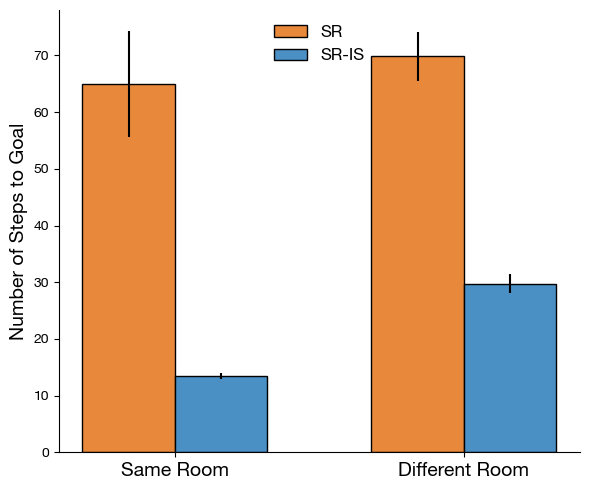

In [46]:
# Set style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue']

# save_path = None
save_path = save_dir + "four-room-replan_final.png"
# save_path = None

plt.figure(figsize=(6, 5))

bar_width = 0.32
r1 = np.arange(2)
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]


# plt.bar(r1, [means[0], means[3]], width=bar_width, label='Random', 
#         color=palette[0], yerr=[sems[0], sems[3]], capsize=0, 
#         edgecolor='black', linewidth=1)
plt.bar(r1, [means[1], means[4]], width=bar_width, label='SR', 
        color=MODEL_COLORS['SR'], yerr=[sems[1], sems[4]], capsize=0, 
        edgecolor='black', linewidth=1)
plt.bar(r2, [means[2], means[5]], width=bar_width, label='SR-IS', 
        color=MODEL_COLORS['SR-IS'], yerr=[sems[2], sems[5]], capsize=0, 
        edgecolor='black', linewidth=1)

plt.ylabel(f'Number of Steps to Goal', fontsize=14)

plt.xticks([r + bar_width/2 for r in range(2)], ['Same Room', 'Different Room'], fontsize=14)

plt.legend(fontsize=12, loc='upper center', frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if save_path:
    plt.savefig(save_path, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()